# FIT3182 Assignment 2 — Data Visualisation

## Task 2.2.1 — Violation Counts & Speed Patterns
## Task 2.2.2 — Interesting Point Annotation

Two subplots arranged side-by-side:
- **Left** — Daily violation counts over time (INSTANTANEOUS vs AVERAGE), 7-day rolling average, shaded peak zone, percentile reference lines, max/min callouts.
- **Right** — Individual violation speeds over arrival time, percentile-coloured scatter, rolling mean, speed-limit lines, spike/drop detection, dynamically labelled percentiles.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pymongo import MongoClient
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'font.family': 'DejaVu Sans'})

mg_db_url = 'mongodb://localhost:27017/'
db_name   = 'AWAS_speed_violations'
client    = MongoClient(mg_db_url)
db        = client[db_name]

os.makedirs('../outputs', exist_ok=True)

In [2]:
# ── Query violations from MongoDB ─────────────────────────────────────────
pipeline = [
    {'$unwind': '$violations'},
    {'$project': {
        'car_plate': 1, 'date': 1,
        'violation_type':  '$violations.violation_type',
        'camera_id_start': '$violations.camera_id_start',
        'camera_id_end':   '$violations.camera_id_end',
        'timestamp_start': '$violations.timestamp_start',
        'timestamp_end':   '$violations.timestamp_end',
        'speed_reading':   '$violations.speed_reading',
        'speed_limit':     '$violations.speed_limit',
        'excess_kmh':      '$violations.excess_kmh'
    }}
]

records = list(db.violations.aggregate(pipeline, allowDiskUse=True))

if records:
    viols_df = pd.DataFrame(records)
    viols_df['date']            = pd.to_datetime(viols_df['date'])
    viols_df['timestamp_start'] = pd.to_datetime(viols_df['timestamp_start'], errors='coerce')
    viols_df['timestamp_end']   = pd.to_datetime(viols_df['timestamp_end'],   errors='coerce')
    print(f'Loaded {len(viols_df):,} violations from MongoDB')
    print(viols_df['violation_type'].value_counts().to_dict())
else:
    # Fallback demo data when streaming has not run yet
    print('No MongoDB data — generating demo dataset.')
    np.random.seed(42)
    dates = pd.date_range('2024-01-01', '2024-08-27', freq='D')
    rows  = []
    for d in dates:
        for _ in range(np.random.poisson(15)):
            ts = d + timedelta(hours=8 + np.random.exponential(3))
            rows.append({'date': d, 'violation_type': 'INSTANTANEOUS',
                         'speed_reading': 110 + np.random.exponential(15),
                         'speed_limit': 110, 'excess_kmh': np.random.exponential(15),
                         'timestamp_start': ts, 'timestamp_end': ts,
                         'camera_id_start': np.random.choice([1, 2, 3]),
                         'camera_id_end':   np.random.choice([1, 2, 3])})
        for _ in range(np.random.poisson(8)):
            ts_s = d + timedelta(hours=8 + np.random.exponential(3))
            ts_e = ts_s + timedelta(seconds=np.random.uniform(20, 55))
            rows.append({'date': d, 'violation_type': 'AVERAGE',
                         'speed_reading': 90 + np.random.exponential(20),
                         'speed_limit': np.random.choice([110, 90]),
                         'excess_kmh': np.random.exponential(20),
                         'timestamp_start': ts_s, 'timestamp_end': ts_e,
                         'camera_id_start': np.random.choice([1, 2]),
                         'camera_id_end':   np.random.choice([2, 3])})
    viols_df = pd.DataFrame(rows)
    viols_df['date'] = pd.to_datetime(viols_df['date'])
    print(f'Generated {len(viols_df):,} demo violations')

No MongoDB data — generating demo dataset.
Generated 5,562 demo violations


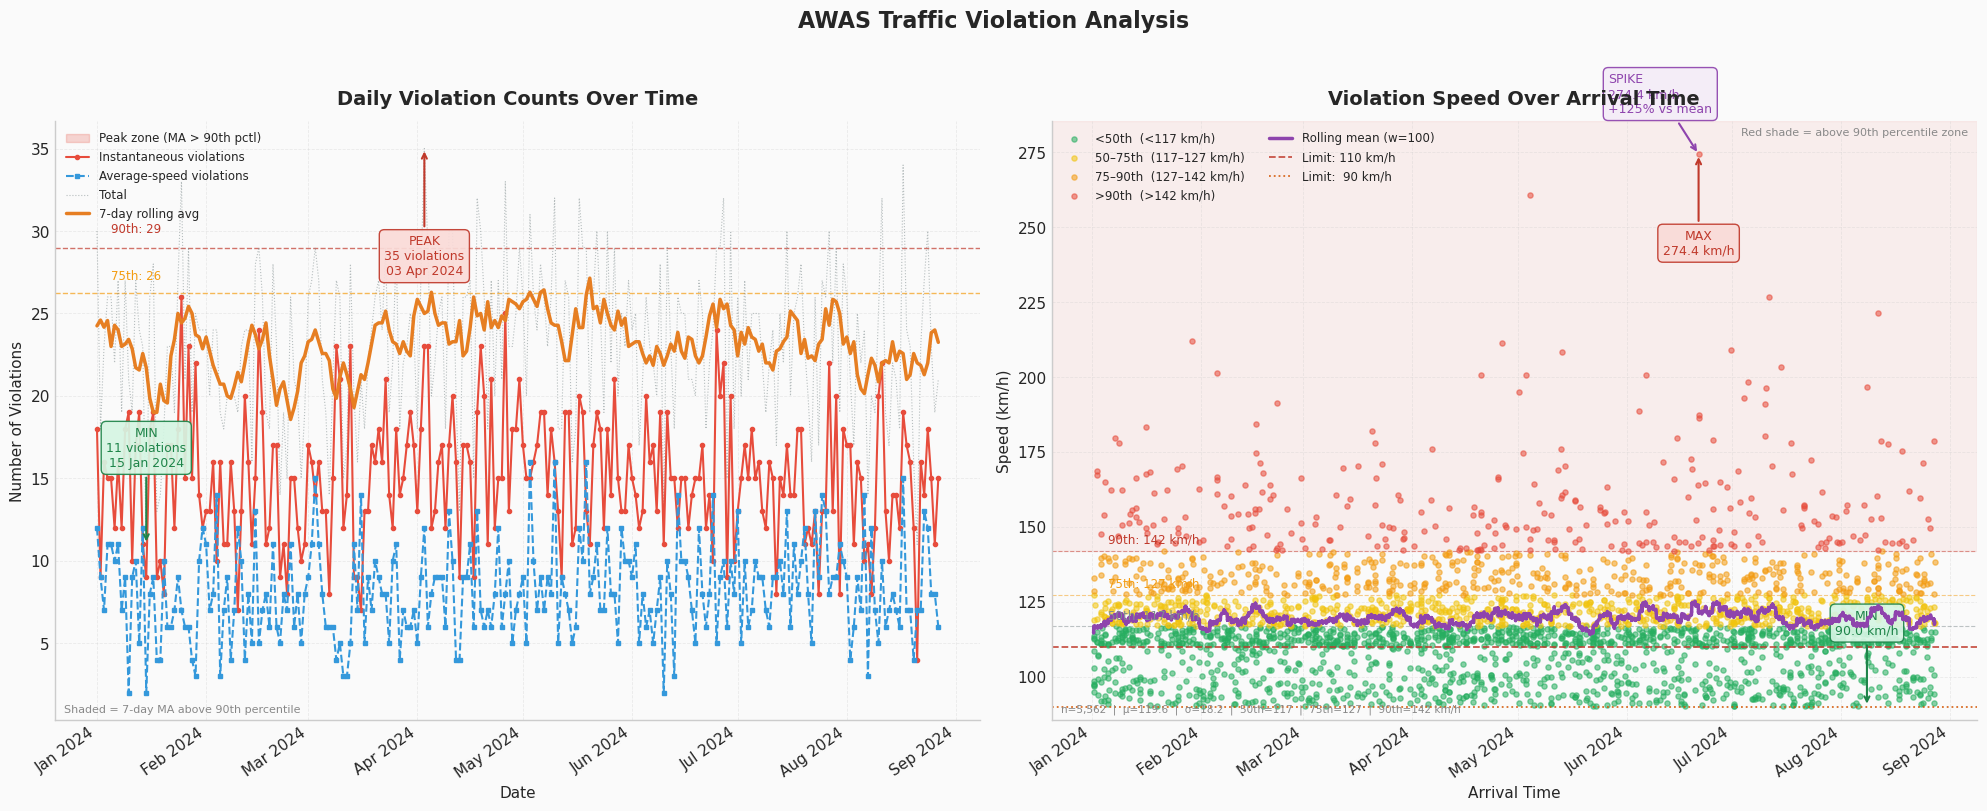

Saved: outputs/awas_violations_analysis.png


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Task 2.2.1 + 2.2.2 — HD Side-by-Side Visualisation
# ═══════════════════════════════════════════════════════════════════════════

# ── Plot 1 data: daily counts ──────────────────────────────────────────────
daily = (
    viols_df
    .groupby([pd.Grouper(key='date', freq='D'), 'violation_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['INSTANTANEOUS', 'AVERAGE'], fill_value=0)
)
daily['total'] = daily.sum(axis=1)
daily['MA_7']  = daily['total'].rolling(7, min_periods=1, center=True).mean()

# Dynamically compute count percentiles
p75_cnt = daily['total'].quantile(0.75)
p90_cnt = daily['total'].quantile(0.90)

# ── Plot 2 data: individual speed readings ─────────────────────────────────
viols_df['ts'] = viols_df['timestamp_start'].fillna(viols_df['timestamp_end']).fillna(viols_df['date'])
viols_ts = viols_df.dropna(subset=['ts']).sort_values('ts').reset_index(drop=True)

W = min(100, max(10, len(viols_ts) // 20))        # adaptive rolling window
viols_ts['roll_mean'] = viols_ts['speed_reading'].rolling(W, min_periods=1, center=True).mean()

# Dynamically compute speed percentiles
p50_spd = viols_ts['speed_reading'].quantile(0.50)
p75_spd = viols_ts['speed_reading'].quantile(0.75)
p90_spd = viols_ts['speed_reading'].quantile(0.90)

def speed_tier_color(s):
    if s > p90_spd: return '#E74C3C'
    if s > p75_spd: return '#F39C12'
    if s > p50_spd: return '#F1C40F'
    return '#27AE60'

viols_ts['pt_color'] = viols_ts['speed_reading'].apply(speed_tier_color)
scatter_df = viols_ts.sample(min(3000, len(viols_ts)), random_state=42).sort_values('ts')

# ── Figure ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('#FAFAFA')
for ax in (ax1, ax2):
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.35, linestyle='--', linewidth=0.6)

# ──────────────────────────────────────────────────────────────────────────
# LEFT — Daily Violation Count Over Time
# ──────────────────────────────────────────────────────────────────────────

# Shaded peak zone: 7-day MA above 90th percentile
ax1.fill_between(daily.index, daily['MA_7'], p90_cnt,
                 where=(daily['MA_7'] >= p90_cnt),
                 alpha=0.22, color='#E74C3C', interpolate=True,
                 label='Peak zone (MA > 90th pctl)')

# Main lines
ax1.plot(daily.index, daily['INSTANTANEOUS'],
         color='#E74C3C', lw=1.5, marker='o', ms=3,
         label='Instantaneous violations', zorder=3)
ax1.plot(daily.index, daily['AVERAGE'],
         color='#3498DB', lw=1.5, marker='s', ms=3, linestyle='--',
         label='Average-speed violations', zorder=3)
ax1.plot(daily.index, daily['total'],
         color='#7F8C8D', lw=0.8, linestyle=':', alpha=0.55,
         label='Total', zorder=2)
ax1.plot(daily.index, daily['MA_7'],
         color='#E67E22', lw=2.5, label='7-day rolling avg', zorder=4)

# Percentile horizontal reference lines + inline labels
label_x = daily.index[max(0, int(len(daily) * 0.02))]
for pval, pclr, plabel in [(p75_cnt, '#F39C12', '75th'), (p90_cnt, '#C0392B', '90th')]:
    ax1.axhline(pval, color=pclr, lw=1.0, linestyle='--', alpha=0.7, zorder=1)
    ax1.text(label_x, pval * 1.025, f'{plabel}: {pval:.0f}',
             color=pclr, fontsize=8.5, va='bottom', zorder=5)

# Annotation — PEAK (max total count)
max_idx = daily['total'].idxmax()
max_val = daily['total'].max()
ax1.annotate(
    f'PEAK\n{int(max_val)} violations\n{max_idx.strftime("%d %b %Y")}',
    xy=(max_idx, max_val), xytext=(0, -62), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', fc='#FADBD8', ec='#C0392B', alpha=0.92),
    fontsize=9, color='#C0392B', ha='center', va='top'
)

# Annotation — MIN (lowest non-zero day)
nz = daily[daily['total'] > 0]['total']
min_idx, min_val = nz.idxmin(), nz.min()
ax1.annotate(
    f'MIN\n{int(min_val)} violations\n{min_idx.strftime("%d %b %Y")}',
    xy=(min_idx, min_val), xytext=(0, 54), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#1E8449', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', fc='#D5F5E3', ec='#1E8449', alpha=0.92),
    fontsize=9, color='#1E8449', ha='center', va='bottom'
)

ax1.set_title('Daily Violation Counts Over Time', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Number of Violations', fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=35, ha='right')
ax1.legend(loc='upper left', fontsize=8.5, framealpha=0.9)
ax1.text(0.01, 0.01, 'Shaded = 7-day MA above 90th percentile',
         transform=ax1.transAxes, fontsize=8, color='#888', ha='left', va='bottom')

# ──────────────────────────────────────────────────────────────────────────
# RIGHT — Violation Speed Over Arrival Time
# ──────────────────────────────────────────────────────────────────────────
y_max = viols_ts['speed_reading'].max() * 1.04

# Shaded zone above 90th percentile
ax2.axhspan(p90_spd, y_max, alpha=0.07, color='#E74C3C', zorder=0)

# Percentile-coloured scatter
tier_cfg = [
    ('#27AE60', f'<50th  (<{p50_spd:.0f} km/h)'),
    ('#F1C40F', f'50–75th  ({p50_spd:.0f}–{p75_spd:.0f} km/h)'),
    ('#F39C12', f'75–90th  ({p75_spd:.0f}–{p90_spd:.0f} km/h)'),
    ('#E74C3C', f'>90th  (>{p90_spd:.0f} km/h)'),
]
for clr, label in tier_cfg:
    mask = scatter_df['pt_color'] == clr
    ax2.scatter(scatter_df[mask]['ts'], scatter_df[mask]['speed_reading'],
                c=clr, s=14, alpha=0.55, zorder=2, label=label)

# Rolling mean line
ax2.plot(viols_ts['ts'], viols_ts['roll_mean'],
         color='#8E44AD', lw=2.5, label=f'Rolling mean (w={W})', zorder=4)

# Speed limit reference lines
ax2.axhline(110, color='#C0392B', lw=1.3, linestyle='--', alpha=0.85, label='Limit: 110 km/h')
ax2.axhline(90,  color='#D35400', lw=1.3, linestyle=':',  alpha=0.85, label='Limit:  90 km/h')

# Dynamically labelled percentile reference lines
ts_label = viols_ts['ts'].iloc[int(len(viols_ts) * 0.02)]
for pval, plabel, pclr in [(p50_spd, '50th', '#7F8C8D'),
                            (p75_spd, '75th', '#F39C12'),
                            (p90_spd, '90th', '#C0392B')]:
    ax2.axhline(pval, color=pclr, lw=0.8, linestyle='--', alpha=0.5, zorder=1)
    ax2.text(ts_label, pval * 1.012, f'{plabel}: {pval:.0f} km/h',
             va='bottom', color=pclr, fontsize=8.5, zorder=5)

# Annotation — MAX speed
row_max = viols_ts.loc[viols_ts['speed_reading'].idxmax()]
ax2.annotate(
    f'MAX\n{row_max["speed_reading"]:.1f} km/h',
    xy=(row_max['ts'], row_max['speed_reading']),
    xytext=(0, -54), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', fc='#FADBD8', ec='#C0392B', alpha=0.92),
    fontsize=9, color='#C0392B', ha='center', va='top'
)

# Annotation — MIN speed
row_min = viols_ts.loc[viols_ts['speed_reading'].idxmin()]
ax2.annotate(
    f'MIN\n{row_min["speed_reading"]:.1f} km/h',
    xy=(row_min['ts'], row_min['speed_reading']),
    xytext=(0, 50), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#1E8449', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', fc='#D5F5E3', ec='#1E8449', alpha=0.92),
    fontsize=9, color='#1E8449', ha='center', va='bottom'
)

# Annotation — Biggest spike above rolling mean (>20% above)
spike_mask = viols_ts['speed_reading'] > viols_ts['roll_mean'] * 1.20
if spike_mask.any():
    spike_row = viols_ts[spike_mask].nlargest(1, 'speed_reading').iloc[0]
    pct_above = (spike_row['speed_reading'] / spike_row['roll_mean'] - 1) * 100
    ax2.annotate(
        f'SPIKE\n{spike_row["speed_reading"]:.1f} km/h\n+{pct_above:.0f}% vs mean',
        xy=(spike_row['ts'], spike_row['speed_reading']),
        xytext=(-65, 30), textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color='#8E44AD', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.4', fc='#F4ECF7', ec='#8E44AD', alpha=0.92),
        fontsize=9, color='#8E44AD'
    )

ax2.set_title('Violation Speed Over Arrival Time', fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Arrival Time', fontsize=11)
ax2.set_ylabel('Speed (km/h)', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=35, ha='right')
ax2.legend(loc='upper left', fontsize=8.5, framealpha=0.9, ncol=2)
ax2.set_ylim(bottom=viols_ts['speed_reading'].min() * 0.95, top=y_max)

# Dynamic percentile stats footer
stats_txt = (
    f"n={len(viols_ts):,}  |  "
    f"\u03bc={viols_ts['speed_reading'].mean():.1f}  |  "
    f"\u03c3={viols_ts['speed_reading'].std():.1f}  |  "
    f"50th={p50_spd:.0f}  |  75th={p75_spd:.0f}  |  90th={p90_spd:.0f} km/h"
)
ax2.text(0.01, 0.01, stats_txt, transform=ax2.transAxes,
         fontsize=7.5, color='#888', ha='left', va='bottom')
ax2.text(0.99, 0.99, 'Red shade = above 90th percentile zone',
         transform=ax2.transAxes, fontsize=8, color='#888', ha='right', va='top')

# ── Master title + save ────────────────────────────────────────────────────
fig.suptitle('AWAS Traffic Violation Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/awas_violations_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Saved: outputs/awas_violations_analysis.png')

---
## Task 2.2.2 — Operational Significance of Annotations

### What each annotation conveys

| Annotation | Plot | Operational value |
|---|---|---|
| **PEAK callout** (max violation day) | Left | Flags the single worst enforcement day — correlate with public holidays, weather events, or road works to understand root causes. |
| **MIN callout** (lowest non-zero day) | Left | Identifies periods of low violation activity — useful for evaluating whether enforcement campaigns reduced violations. |
| **Shaded peak zone** (7-day MA > 90th pctl) | Left | Highlights sustained high-violation periods rather than isolated outliers, enabling targeted enforcement scheduling. |
| **75th / 90th percentile lines** (count) | Left | Dynamic thresholds — any day above the 90th line is in the top 10% of violation frequency and warrants investigation. |
| **MAX / MIN speed callouts** | Right | Identifies the single most dangerous recorded event and the lowest marginal offender — helps calibrate enforcement severity. |
| **SPIKE annotation** (>20% above rolling mean) | Right | Sudden jumps in violation speed, often caused by isolated road events or camera calibration anomalies, are flagged for review. |
| **50th / 75th / 90th speed percentile lines** | Right | Dynamically computed — offenders above the 90th percentile are the highest-risk cohort and should be prioritised for enforcement. |
| **Shaded zone** (speed > 90th pctl) | Right | Visual emphasis on the most dangerous speed band, aligned with the 90th percentile threshold. |

### Recommendations
1. **Target enforcement** on days when the 7-day MA exceeds the 90th percentile count threshold.
2. **Investigate SPIKE events** — a speed >20% above the rolling mean may indicate a data anomaly or an exceptional dangerous driving incident.
3. **Prioritise prosecution** of offenders in the red tier (>90th percentile speed) — they represent the top 10% of severity.
4. **Track the MIN trend** over time: if minimum-violation days shift later in the year, enforcement campaigns are likely having an effect.

In [4]:
client.close()
print('MongoDB connection closed.')

MongoDB connection closed.
